In [42]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os
import sys
import globals.path as pth
import globals.design as dn
from util.util import lowpass_butter
from behavioural.force import load_mov
from vis import plot_behav, plot_rep
plt.style.use('default')

figDir = pth.figDir

In [43]:
path = os.path.join(pth.baseDir, 'behavioural', 'single_trial_behaviour.tsv')
dat = pd.read_csv(path, sep='\t')
dat.Repetition = pd.Categorical(dat.Repetition, categories=[1, 2])
dat_corr = dat[dat.trialPoint == 1]
N = len(dat.subNum.unique())
print(f'N={N}')

N=9


load_mov...reading trial: 0
load_mov...reading trial: 1
load_mov...reading trial: 2
load_mov...reading trial: 3
load_mov...reading trial: 4
load_mov...reading trial: 5
load_mov...reading trial: 6
load_mov...reading trial: 7
load_mov...reading trial: 8
load_mov...reading trial: 9
load_mov...reading trial: 10
load_mov...reading trial: 11
load_mov...reading trial: 12
load_mov...reading trial: 13
load_mov...reading trial: 14
load_mov...reading trial: 15
load_mov...reading trial: 16
load_mov...reading trial: 17
load_mov...reading trial: 18
load_mov...reading trial: 19
load_mov...reading trial: 20
load_mov...reading trial: 21
load_mov...reading trial: 22
load_mov...reading trial: 23
load_mov...reading trial: 24
load_mov...reading trial: 25
load_mov...reading trial: 26
load_mov...reading trial: 27
load_mov...reading trial: 28
load_mov...reading trial: 29
load_mov...reading trial: 30
load_mov...reading trial: 31
load_mov...reading trial: 32
load_mov...reading trial: 33
load_mov...reading trial

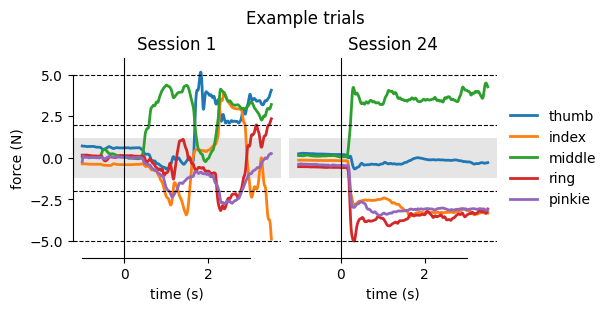

In [44]:
sn = 101
bl = 1
session  = [1, 24]
ntrial = [12, 15]  # chord 92122
ch_idx = np.array(dn.diffCols)

fig, axs = plt.subplots(1, 2, sharey=True, figsize=(6, 3), constrained_layout=True,)

tAx = np.linspace(-1, 3.5, int(dn.fsample['force'] * 4.5))

for s, sess in enumerate(session):
    ax = axs[s]
    filename = os.path.join(pth.baseDir, 'behavioural', f'day{sess}', f'efc4_{sn}_{bl:02d}.mov')
    mov = load_mov(filename)[ntrial[s]]
    mov = mov[(mov[:, 1] == dn.wait_exec) | (mov[:, 1] == dn.wait_exec - 1)]
    force = mov[:, ch_idx] * dn.fGain
    force_lp = lowpass_butter(force, cutoff=20, fsample=dn.fsample['force'], axis=0)
    ax.plot(tAx, force_lp, lw=2, label=['thumb', 'index', 'middle', 'ring', 'pinkie'])
    ax.set_title(f'Session {sess}')
    ax.axhspan(-dn.fthresh, dn.fthresh, color='grey', alpha=0.2, lw=0)
    ax.axvline(0, color='k', lw=.8)
    ax.axhline(2, color='k', lw=.8, ls='--')
    ax.axhline(-2, color='k', lw=.8, ls='--')
    ax.axhline(5, color='k', lw=.8, ls='--')
    ax.axhline(-5, color='k', lw=.8, ls='--')
    ax.set_ylabel('force (N)') if s == 0 else None
    ax.set_xlabel('time (s)')
    ax.set_ylim([-6, 6])
    ax.tick_params(axis='y', left=False) if s == 1 else None
    ax.set_yticks([-5, -2.5, 0, 2.5, 5])
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['left'].set_visible(False) if s==1 else None
    ax.spines['bottom'].set_bounds(-1, 3)
    ax.spines['left'].set_bounds(-5, 5)
    ax.legend(bbox_to_anchor=(1, .5), loc='center left', frameon=False) if s==1 else None

fig.suptitle('Example trials')
fig.savefig(os.path.join(figDir, 'example_force.pdf'))

plt.show()

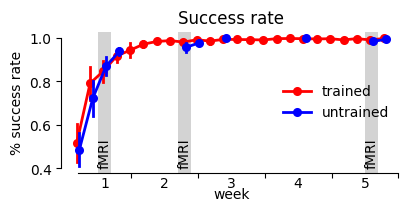

In [45]:
dat_sess = dat.groupby(['subNum', 'session', 'chord']).mean(numeric_only=True).reset_index()
fig, ax = plt.subplots(figsize=(4,2), constrained_layout=True)
sb.pointplot(ax=ax, x='session', y='trialPoint', hue='chord',dodge=.2, data=dat_sess, errorbar='se', palette=['red', 'blue'],hue_order=['trained', 'untrained'], lw=2)
ax.set_ylabel('% success rate')
ax.set_title('Success rate')
ax.set_xlabel('')
ax.set_xticks(np.array([4, 9, 14, 19, 24]))
ax.set_xticklabels([])
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_bounds(0, 24)
ax.spines['left'].set_bounds(.4, 1)
ax.axvspan(1.5, 2.5, facecolor='lightgrey')
ax.axvspan(7.5, 8.5, facecolor='lightgrey')
ax.axvspan(21.5, 22.5, facecolor='lightgrey')
ax.text(2, .4, 'fMRI', rotation=90, ha='center', va='bottom')
ax.text(8, .4, 'fMRI', rotation=90, ha='center', va='bottom')
ax.text(22, .4, 'fMRI', rotation=90, ha='center', va='bottom')
ylim0, ylim1 = ax.get_ylim()[0], ax.get_ylim()[1]
xticks = ylim0 - (.025 * (ylim1 - ylim0))
xlabel = ylim0 - (.1 * (ylim1 - ylim0))
ax.text(2, xticks, '1', ha='center', va='top', transform=ax.transData)
ax.text(6.5, xticks, '2', ha='center', va='top', transform=ax.transData)
ax.text(11.5, xticks, '3', ha='center', va='top', transform=ax.transData)
ax.text(11.5, xlabel, 'week', ha='center', va='top', transform=ax.transData)
ax.text(16.5, xticks, '4', ha='center', va='top', transform=ax.transData)
ax.text(21.5, xticks, '5', ha='center', va='top', transform=ax.transData)
ax.legend(frameon=False, loc='center right')
fig.savefig(os.path.join(figDir, 'success_rate.pdf'))
plt.show()

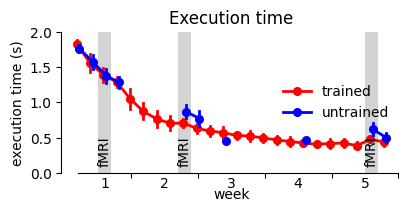

In [46]:
dat_sess_corr = dat_corr.groupby(['subNum', 'session', 'chord']).mean(numeric_only=True).reset_index()
fig, ax = plt.subplots(figsize=(4,2), constrained_layout=True)
sb.pointplot(ax=ax, x='session', y='ET', hue='chord', dodge=.2,data=dat_sess_corr, errorbar='se', palette=['red', 'blue'],hue_order=['trained', 'untrained'], lw=2)
ax.set_ylabel('execution time (s)')
ax.set_title('Execution time')
ax.set_xlabel('')
ax.set_xticks(np.array([4, 9, 14, 19, 24]))
ax.set_xticklabels([])
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_bounds(0, 24)
ax.spines['left'].set_bounds(0, 2)
ax.set_ylim((0, 2))
ax.axvspan(1.5, 2.5, facecolor='lightgrey')
ax.axvspan(7.5, 8.5, facecolor='lightgrey')
ax.axvspan(21.5, 22.5, facecolor='lightgrey')
ax.text(2, .1, 'fMRI', rotation=90, ha='center', va='bottom')
ax.text(8, .1, 'fMRI', rotation=90, ha='center', va='bottom')
ax.text(22, .1, 'fMRI', rotation=90, ha='center', va='bottom')
ylim0, ylim1 = ax.get_ylim()[0], ax.get_ylim()[1]
xticks = ylim0 - (.025 * (ylim1 - ylim0))
xlabel = ylim0 - (.1 * (ylim1 - ylim0))
ax.text(2, xticks, '1', ha='center', va='top', transform=ax.transData)
ax.text(6.5, xticks, '2', ha='center', va='top', transform=ax.transData)
ax.text(11.5, xticks, '3', ha='center', va='top', transform=ax.transData)
ax.text(11.5, xlabel, 'week', ha='center', va='top', transform=ax.transData)
ax.text(16.5, xticks, '4', ha='center', va='top', transform=ax.transData)
ax.text(21.5, xticks, '5', ha='center', va='top', transform=ax.transData)
ax.legend(frameon=False, loc='center right')
fig.savefig(os.path.join(figDir, 'execution_time.pdf'))
plt.show()

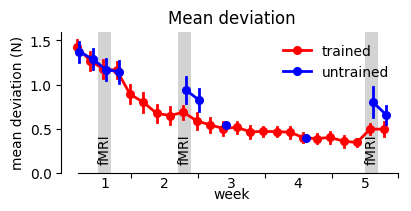

In [47]:
fig, ax = plt.subplots(figsize=(4,2), constrained_layout=True)
sb.pointplot(ax=ax, x='session', y='MD', hue='chord', dodge=.2,data=dat_sess_corr, errorbar='se', palette=['red', 'blue'],hue_order=['trained', 'untrained'], lw=2)
ax.set_ylabel('mean deviation (N)')
ax.set_title('Mean deviation')
ax.set_xticks(np.array([4, 9, 14, 19, 24]))
ax.set_xticklabels([])
ax.set_xlabel('')
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_bounds(0, 24)
ax.spines['left'].set_bounds(0, 1.6)
ax.set_ylim((0, 1.6))
ax.axvspan(1.5, 2.5, facecolor='lightgrey')
ax.axvspan(7.5, 8.5, facecolor='lightgrey')
ax.axvspan(21.5, 22.5, facecolor='lightgrey')
ax.text(2, .1, 'fMRI', rotation=90, ha='center', va='bottom')
ax.text(8, .1, 'fMRI', rotation=90, ha='center', va='bottom')
ax.text(22, .1, 'fMRI', rotation=90, ha='center', va='bottom')
ylim0, ylim1 = ax.get_ylim()[0], ax.get_ylim()[1]
xticks = ylim0 - (.025 * (ylim1 - ylim0))
xlabel = ylim0 - (.1 * (ylim1 - ylim0))
ax.text(2, xticks, '1', ha='center', va='top', transform=ax.transData)
ax.text(6.5, xticks, '2', ha='center', va='top', transform=ax.transData)
ax.text(11.5, xticks, '3', ha='center', va='top', transform=ax.transData)
ax.text(11.5, xlabel, 'week', ha='center', va='top', transform=ax.transData)
ax.text(16.5, xticks, '4', ha='center', va='top', transform=ax.transData)
ax.text(21.5, xticks, '5', ha='center', va='top', transform=ax.transData)
ax.legend(frameon=False, loc='upper right')
fig.savefig(os.path.join(figDir, 'mean_deviation.pdf'))
plt.show()

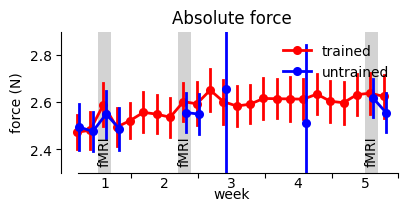

In [48]:
dat_sess_corr_melt = dat_sess_corr.melt(id_vars=['subNum', 'chordID', 'chord', 'TN', 'BN', 'session'],value_vars=['thumb_abs', 'index_abs', 'middle_abs', 'ring_abs', 'pinkie_abs'], var_name='finger', value_name='force')
fig, ax = plt.subplots(figsize=(4, 2), constrained_layout=True)
sb.pointplot(ax=ax, x='session', y='force', hue='chord', dodge=.2,data=dat_sess_corr_melt, errorbar='se', palette=['red', 'blue'],hue_order=['trained', 'untrained'], lw=2)
ax.set_ylabel('force (N)')
ax.set_title('Absolute force')
ax.set_xlabel('')
ax.set_xticks(np.array([4, 9, 14, 19, 24]))
ax.set_xticklabels([])
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_bounds(0, 24)
#ax.spines['left'].set_bounds(0, 1.6)
ax.set_ylim((2.3, 2.9))
ax.axvspan(1.5, 2.5, facecolor='lightgrey')
ax.axvspan(7.5, 8.5, facecolor='lightgrey')
ax.axvspan(21.5, 22.5, facecolor='lightgrey')
ax.text(2, 2.33, 'fMRI', rotation=90, ha='center', va='bottom')
ax.text(8, 2.33, 'fMRI', rotation=90, ha='center', va='bottom')
ax.text(22, 2.33, 'fMRI', rotation=90, ha='center', va='bottom')
ylim0, ylim1 = ax.get_ylim()[0], ax.get_ylim()[1]
xticks = ylim0 - (.025 * (ylim1 - ylim0))
xlabel = ylim0 - (.1 * (ylim1 - ylim0))
ax.text(2, xticks, '1', ha='center', va='top', transform=ax.transData)
ax.text(6.5, xticks, '2', ha='center', va='top', transform=ax.transData)
ax.text(11.5, xticks, '3', ha='center', va='top', transform=ax.transData)
ax.text(11.5, xlabel, 'week', ha='center', va='top', transform=ax.transData)
ax.text(16.5, xticks, '4', ha='center', va='top', transform=ax.transData)
ax.text(21.5, xticks, '5', ha='center', va='top', transform=ax.transData)
ax.legend(frameon=False, loc='upper right')
fig.savefig(os.path.join(figDir, 'force_abs.pdf'))
plt.show()

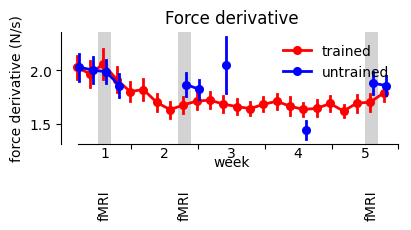

In [49]:
dat_sess_corr_melt = dat_sess_corr.melt(id_vars=['subNum', 'chordID', 'chord', 'TN', 'BN', 'session'],value_vars=['thumb_der', 'index_der', 'middle_der', 'ring_der', 'pinkie_der'], var_name='finger', value_name='force_der')
fig, ax = plt.subplots(figsize=(4, 2), constrained_layout=True)
sb.pointplot(ax=ax, x='session', y='force_der', hue='chord', dodge=.2, data=dat_sess_corr_melt, errorbar='se', palette=['red', 'blue'],hue_order=['trained', 'untrained'], lw=2)
ax.set_ylabel('force derivative (N/s)')
ax.set_title('Force derivative')
ax.set_xlabel('')
ax.set_xticks(np.array([4, 9, 14, 19, 24]))
ax.set_xticklabels([])
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_bounds(0, 24)
#ax.spines['left'].set_bounds(0, 1.6)
#ax.set_ylim((.59, .8))
ax.axvspan(1.5, 2.5, facecolor='lightgrey')
ax.axvspan(7.5, 8.5, facecolor='lightgrey')
ax.axvspan(21.5, 22.5, facecolor='lightgrey')
ax.text(2, .6, 'fMRI', rotation=90, ha='center', va='bottom')
ax.text(8, .6, 'fMRI', rotation=90, ha='center', va='bottom')
ax.text(22, .6, 'fMRI', rotation=90, ha='center', va='bottom')
ylim0, ylim1 = ax.get_ylim()[0], ax.get_ylim()[1]
xticks = ylim0 - (.025 * (ylim1 - ylim0))
xlabel = ylim0 - (.1 * (ylim1 - ylim0))
ax.text(2, xticks, '1', ha='center', va='top', transform=ax.transData)
ax.text(6.5, xticks, '2', ha='center', va='top', transform=ax.transData)
ax.text(11.5, xticks, '3', ha='center', va='top', transform=ax.transData)
ax.text(11.5, xlabel, 'week', ha='center', va='top', transform=ax.transData)
ax.text(16.5, xticks, '4', ha='center', va='top', transform=ax.transData)
ax.text(21.5, xticks, '5', ha='center', va='top', transform=ax.transData)
ax.legend(frameon=False, loc='upper right')
fig.savefig(os.path.join(figDir, 'force_der.pdf'))
plt.show()

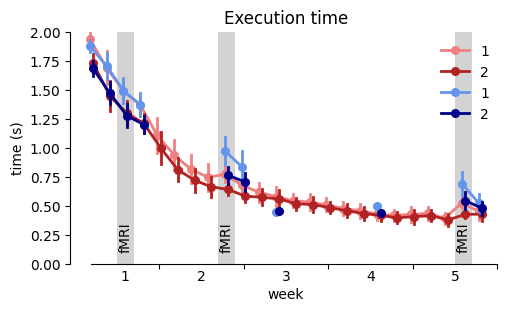

In [50]:
dat_rep = dat_corr.groupby(['subNum', 'session', 'chord', 'Repetition'], observed=True).mean(numeric_only=True).reset_index()
fig, ax = plt.subplots(figsize=(5,3), constrained_layout=True)
sb.pointplot(ax=ax, x='session', y='ET', hue='Repetition', dodge=.2, data=dat_rep[dat_rep['chord']=='trained'], errorbar='se', palette=['lightcoral', 'firebrick'], lw=2)
#ax.legend(frameon=False, loc='upper right', title='Trained')
sb.pointplot(ax=ax, x='session', y='ET', hue='Repetition', dodge=.2, data=dat_rep[dat_rep['chord']=='untrained'], errorbar='se', palette=['cornflowerblue', 'darkblue'], lw=2)
ax.legend(frameon=False, loc='upper right')
ax.set_ylabel('time (s)')
ax.set_title('Execution time')
ax.set_xticks(np.array([4, 9, 14, 19, 24]))
ax.set_xticklabels([])
ax.set_xlabel('')
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_bounds(0, 24)
ax.spines['left'].set_bounds(0, 2)
ax.set_ylim((0, 2))
ax.axvspan(1.5, 2.5, facecolor='lightgrey')
ax.axvspan(7.5, 8.5, facecolor='lightgrey')
ax.axvspan(21.5, 22.5, facecolor='lightgrey')
ax.text(2, .1, 'fMRI', rotation=90, ha='center', va='bottom')
ax.text(8, .1, 'fMRI', rotation=90, ha='center', va='bottom')
ax.text(22, .1, 'fMRI', rotation=90, ha='center', va='bottom')
ylim0, ylim1 = ax.get_ylim()[0], ax.get_ylim()[1]
xticks = ylim0 - (.025 * (ylim1 - ylim0))
xlabel = ylim0 - (.1 * (ylim1 - ylim0))
ax.text(2, xticks, '1', ha='center', va='top', transform=ax.transData)
ax.text(6.5, xticks, '2', ha='center', va='top', transform=ax.transData)
ax.text(11.5, xticks, '3', ha='center', va='top', transform=ax.transData)
ax.text(11.5, xlabel, 'week', ha='center', va='top', transform=ax.transData)
ax.text(16.5, xticks, '4', ha='center', va='top', transform=ax.transData)
ax.text(21.5, xticks, '5', ha='center', va='top', transform=ax.transData)
fig.savefig(os.path.join(figDir, 'rep_execution_time.pdf'))
plt.show()

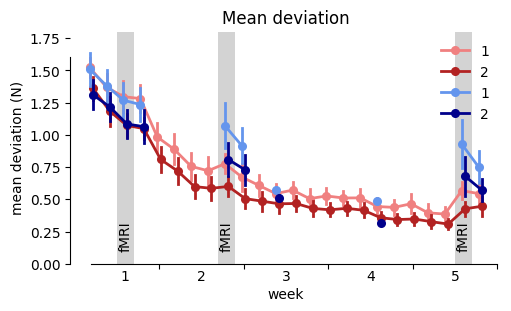

In [51]:
fig, ax = plt.subplots(figsize=(5,3), constrained_layout=True)
sb.pointplot(ax=ax, x='session', y='MD', hue='Repetition', dodge=.2, data=dat_rep[dat_rep['chord']=='trained'], errorbar='se', palette=['lightcoral', 'firebrick'], lw=2)
sb.pointplot(ax=ax, x='session', y='MD', hue='Repetition', dodge=.2, data=dat_rep[dat_rep['chord']=='untrained'], errorbar='se', palette=['cornflowerblue', 'darkblue'], lw=2)
ax.legend(frameon=False, loc='upper right')
ax.set_ylabel('mean deviation (N)')
ax.set_title('Mean deviation')
ax.set_xticks(np.array([4, 9, 14, 19, 24]))
ax.set_xticklabels([])
ax.set_xlabel('')
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_bounds(0, 24)
ax.spines['left'].set_bounds(0, 1.6)
ax.set_ylim((0, 1.8))
ax.axvspan(1.5, 2.5, facecolor='lightgrey')
ax.axvspan(7.5, 8.5, facecolor='lightgrey')
ax.axvspan(21.5, 22.5, facecolor='lightgrey')
ax.text(2, .1, 'fMRI', rotation=90, ha='center', va='bottom')
ax.text(8, .1, 'fMRI', rotation=90, ha='center', va='bottom')
ax.text(22, .1, 'fMRI', rotation=90, ha='center', va='bottom')
ylim0, ylim1 = ax.get_ylim()[0], ax.get_ylim()[1]
xticks = ylim0 - (.025 * (ylim1 - ylim0))
xlabel = ylim0 - (.1 * (ylim1 - ylim0))
ax.text(2, xticks, '1', ha='center', va='top', transform=ax.transData)
ax.text(6.5, xticks, '2', ha='center', va='top', transform=ax.transData)
ax.text(11.5, xticks, '3', ha='center', va='top', transform=ax.transData)
ax.text(11.5, xlabel, 'week', ha='center', va='top', transform=ax.transData)
ax.text(16.5, xticks, '4', ha='center', va='top', transform=ax.transData)
ax.text(21.5, xticks, '5', ha='center', va='top', transform=ax.transData)
fig.savefig(os.path.join(figDir, 'rep_mean_deviation.pdf'))
plt.show()

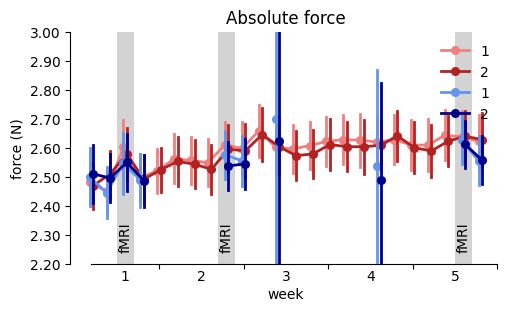

In [52]:
dat_rep_melt = dat_rep.melt(id_vars=['subNum', 'chordID', 'chord', 'TN', 'BN', 'session', 'Repetition'],value_vars=['thumb_abs', 'index_abs', 'middle_abs', 'ring_abs', 'pinkie_abs'], var_name='finger', value_name='force_abs')
fig, ax = plt.subplots(figsize=(5,3), constrained_layout=True)
sb.pointplot(ax=ax, x='session', y='force_abs', hue='Repetition', dodge=.2, data=dat_rep_melt[dat_rep_melt['chord']=='trained'], errorbar='se', palette=['lightcoral', 'firebrick'], lw=2)
sb.pointplot(ax=ax, x='session', y='force_abs', hue='Repetition', dodge=.2, data=dat_rep_melt[dat_rep_melt['chord']=='untrained'], errorbar='se', palette=['cornflowerblue', 'darkblue'], lw=2)
ax.legend(frameon=False, loc='upper right')
ax.set_ylabel('force (N)')
ax.set_title('Absolute force')
ax.set_xticks(np.array([4, 9, 14, 19, 24]))
ax.set_xticklabels([])
ax.set_xlabel('')
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_bounds(0, 24)
ax.spines['left'].set_bounds(2.2, 3)
ax.set_ylim((2.2, 3))
ax.axvspan(1.5, 2.5, facecolor='lightgrey')
ax.axvspan(7.5, 8.5, facecolor='lightgrey')
ax.axvspan(21.5, 22.5, facecolor='lightgrey')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ylim0, ylim1 = ax.get_ylim()[0], ax.get_ylim()[1]
ydiff = (ylim1 - ylim0)
xticks = ylim0 - (.025 * ydiff)
xlabel = ylim0 - (.1 * ydiff)
ax.text(2, ylim0 + .05 * ydiff, 'fMRI', rotation=90, ha='center', va='bottom')
ax.text(8, ylim0 + .05 * ydiff, 'fMRI', rotation=90, ha='center', va='bottom')
ax.text(22, ylim0 + .05 * ydiff, 'fMRI', rotation=90, ha='center', va='bottom')
ax.text(2, xticks, '1', ha='center', va='top', transform=ax.transData)
ax.text(6.5, xticks, '2', ha='center', va='top', transform=ax.transData)
ax.text(11.5, xticks, '3', ha='center', va='top', transform=ax.transData)
ax.text(11.5, xlabel, 'week', ha='center', va='top', transform=ax.transData)
ax.text(16.5, xticks, '4', ha='center', va='top', transform=ax.transData)
ax.text(21.5, xticks, '5', ha='center', va='top', transform=ax.transData)
fig.savefig(os.path.join(figDir, 'rep_force_absolute.pdf'))
plt.show()

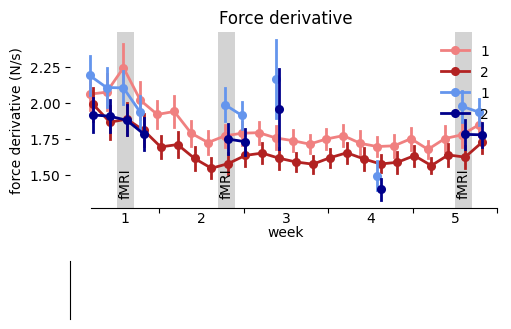

In [53]:
dat_rep_melt = dat_rep.melt(id_vars=['subNum', 'chordID', 'chord', 'TN', 'BN', 'session', 'Repetition'],value_vars=['thumb_der', 'index_der', 'middle_der', 'ring_der', 'pinkie_der'], var_name='finger', value_name='force_der')
fig, ax = plt.subplots(figsize=(5,3), constrained_layout=True)
sb.pointplot(ax=ax, x='session', y='force_der', hue='Repetition', dodge=.2, data=dat_rep_melt[dat_rep_melt['chord']=='trained'], errorbar='se', palette=['lightcoral', 'firebrick'], lw=2)
sb.pointplot(ax=ax, x='session', y='force_der', hue='Repetition', dodge=.2, data=dat_rep_melt[dat_rep_melt['chord']=='untrained'], errorbar='se', palette=['cornflowerblue', 'darkblue'], lw=2)
ax.legend(frameon=False, loc='upper right')
ax.set_ylabel('force derivative (N/s)')
ax.set_title('Force derivative')
ax.set_xticks(np.array([4, 9, 14, 19, 24]))
ax.set_xticklabels([])
ax.set_xlabel('')
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_bounds(0, 24)
ax.spines['left'].set_bounds(.5, .9)
#ax.set_ylim((.5, .9))
ax.axvspan(1.5, 2.5, facecolor='lightgrey')
ax.axvspan(7.5, 8.5, facecolor='lightgrey')
ax.axvspan(21.5, 22.5, facecolor='lightgrey')
ylim0, ylim1 = ax.get_ylim()[0], ax.get_ylim()[1]
ydiff = (ylim1 - ylim0)
xticks = ylim0 - (.025 * ydiff)
xlabel = ylim0 - (.1 * ydiff)
ax.text(2, ylim0 + .05 * ydiff, 'fMRI', rotation=90, ha='center', va='bottom')
ax.text(8, ylim0 + .05 * ydiff, 'fMRI', rotation=90, ha='center', va='bottom')
ax.text(22, ylim0 + .05 * ydiff, 'fMRI', rotation=90, ha='center', va='bottom')
ax.text(2, xticks, '1', ha='center', va='top', transform=ax.transData)
ax.text(6.5, xticks, '2', ha='center', va='top', transform=ax.transData)
ax.text(11.5, xticks, '3', ha='center', va='top', transform=ax.transData)
ax.text(11.5, xlabel, 'week', ha='center', va='top', transform=ax.transData)
ax.text(16.5, xticks, '4', ha='center', va='top', transform=ax.transData)
ax.text(21.5, xticks, '5', ha='center', va='top', transform=ax.transData)
fig.savefig(os.path.join(figDir, 'rep_force_derivative.pdf'))
plt.show()

AttributeError: 'DataFrame' object has no attribute 'day'

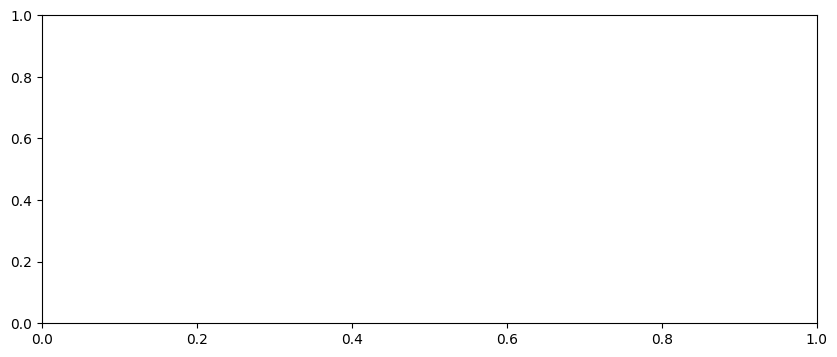

In [54]:
fig, ax = plt.subplots(figsize=(10, 4))
dat_s = dat[dat.trialPoint==1]
plot_behav(fig, ax, dat_s, metric='ET', ylim=[0, 2.2], ylabel='execution time (s)', title='Execution time')
plt.show()

/home/UWO/memanue5/Documents/GitHub/extension-flexion-chords/vis.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat_tmp['BN'] = dat_tmp['BN'] + max_bn
/home/UWO/memanue5/Documents/GitHub/extension-flexion-chords/vis.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat_tmp['BN'] = dat_tmp['BN'] + max_bn
/home/UWO/memanue5/Documents/GitHub/extension-flexion-chords/vis.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_ind

trained vs. untrained, day1: tval=0.839, pval=0.429
trained vs. untrained, day2: tval=-0.363, pval=0.727
trained vs. untrained, day3: tval=0.096, pval=0.926
trained vs. untrained, day4: tval=0.181, pval=0.862
trained vs. untrained, day9: tval=-2.939, pval=0.022
trained vs. untrained, day10: tval=-2.932, pval=0.022
trained vs. untrained, day23: tval=-2.726, pval=0.030
trained vs. untrained, day24: tval=-4.312, pval=0.004


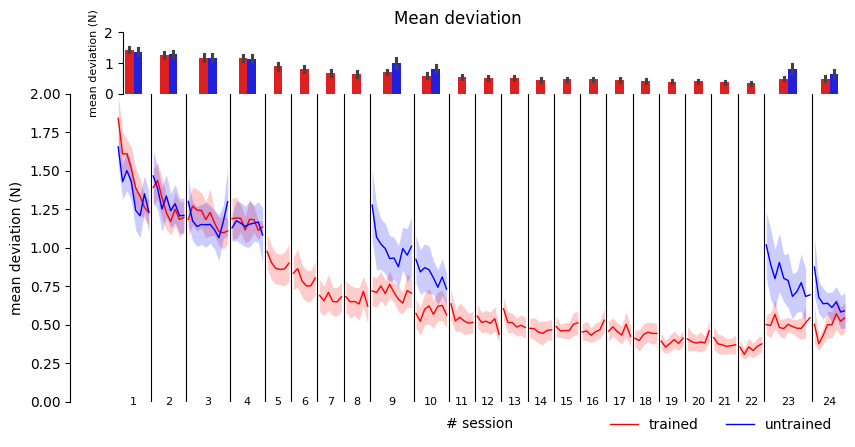

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_behav(fig, ax, dat_s, metric='MD', ylim=[0, 2], ylabel='mean deviation (N)', title='Mean deviation',)
plt.show()

/home/UWO/memanue5/Documents/GitHub/extension-flexion-chords/vis.py:90: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sb.lineplot(data=dat_bn, ax=ax, x='BN', y=metric, hue='chord', errorbar='se', lw=1,
/home/UWO/memanue5/Documents/GitHub/extension-flexion-chords/vis.py:90: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sb.lineplot(data=dat_bn, ax=ax, x='BN', y=metric, hue='chord', errorbar='se', lw=1,
/home/UWO/memanue5/Documents/GitHub/extension-flexion-chords/vis.py:90: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sb.lineplot(data=dat_bn, ax=ax, x='BN', y=metric, hue='chord', errorbar='se', lw=1,
/home/UWO/memanue5/Documents/GitHub/extension-flexion-chords/vis.py:90: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sb.lineplot(data=dat_bn, ax=ax, x='BN', y=metric, hue='chord', errorbar='se'

trained vs. untrained, day1: tval=0.669, pval=0.525
trained vs. untrained, day2: tval=2.134, pval=0.070
trained vs. untrained, day3: tval=0.202, pval=0.845
trained vs. untrained, day4: tval=0.565, pval=0.592
trained vs. untrained, day9: tval=2.540, pval=0.039
trained vs. untrained, day10: tval=1.726, pval=0.128
trained vs. untrained, day23: tval=0.534, pval=0.610
trained vs. untrained, day24: tval=5.507, pval=0.001


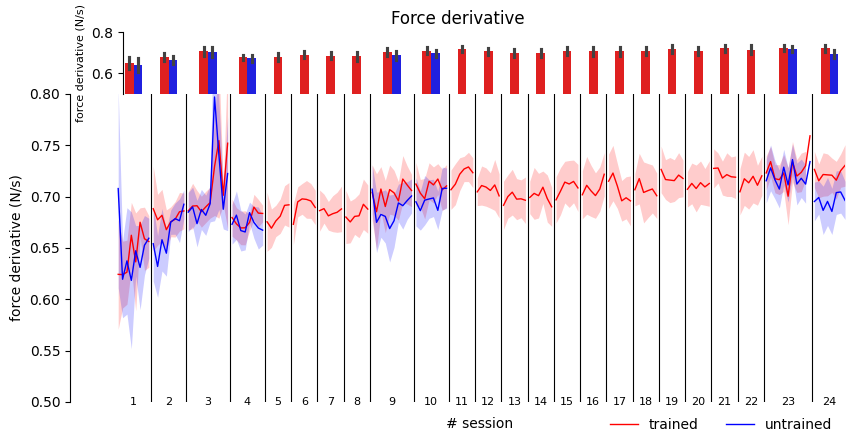

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_behav(fig, ax, dat_s, metric='force_der', ylim=[.5, .8], melt=True, id_vars=['subNum', 'chordID', 'chord', 'TN', 'BN', 'day'],value_vars=['thumb_der', 'index_der', 'middle_der', 'ring_der', 'pinkie_der'], var_name='finger', ylabel='force derivative (N/s)', title='Force derivative', )
plt.show()

/home/UWO/memanue5/Documents/GitHub/extension-flexion-chords/vis.py:90: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sb.lineplot(data=dat_bn, ax=ax, x='BN', y=metric, hue='chord', errorbar='se', lw=1,
/home/UWO/memanue5/Documents/GitHub/extension-flexion-chords/vis.py:90: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sb.lineplot(data=dat_bn, ax=ax, x='BN', y=metric, hue='chord', errorbar='se', lw=1,
/home/UWO/memanue5/Documents/GitHub/extension-flexion-chords/vis.py:90: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sb.lineplot(data=dat_bn, ax=ax, x='BN', y=metric, hue='chord', errorbar='se', lw=1,
/home/UWO/memanue5/Documents/GitHub/extension-flexion-chords/vis.py:90: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sb.lineplot(data=dat_bn, ax=ax, x='BN', y=metric, hue='chord', errorbar='se'

trained vs. untrained, day1: tval=-0.630, pval=0.549
trained vs. untrained, day2: tval=0.196, pval=0.850
trained vs. untrained, day3: tval=1.315, pval=0.230
trained vs. untrained, day4: tval=0.230, pval=0.826
trained vs. untrained, day9: tval=2.590, pval=0.036
trained vs. untrained, day10: tval=2.870, pval=0.024
trained vs. untrained, day23: tval=0.946, pval=0.376
trained vs. untrained, day24: tval=6.536, pval=0.000


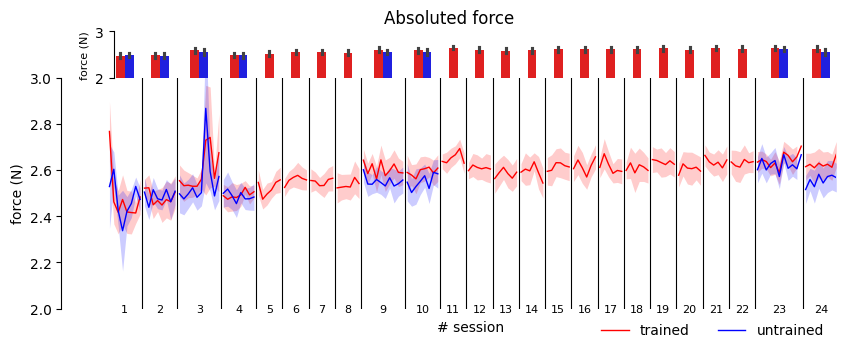

In [18]:
fig, ax = plt.subplots(figsize=(10, 3))
plot_behav(fig, ax, dat_s, metric='force', ylim=[2, 3], melt=True, id_vars=['subNum', 'chordID', 'chord', 'TN', 'BN', 'day'],value_vars=['thumb_abs', 'index_abs', 'middle_abs', 'ring_abs', 'pinkie_abs'], var_name='finger', ylabel='force (N)', title='Absoluted force', )
plt.show()

TypeError: unsupported operand type(s) for +: 'Categorical' and 'int'

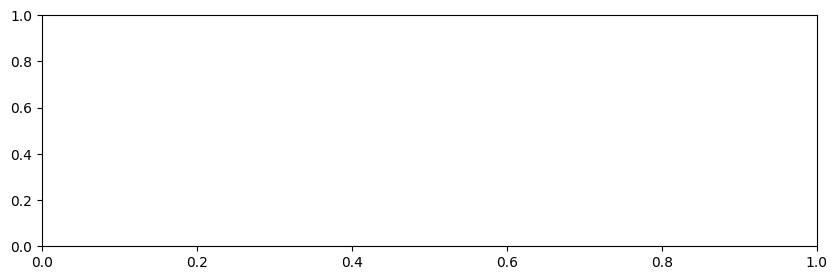

In [19]:
fig, ax = plt.subplots(figsize=(10, 3))
plot_rep(fig, ax, dat_s, metric='ET', ylim=[0, 2.5], ylabel='execution time (s)', title='Repetition effect in execution time')
plt.show()

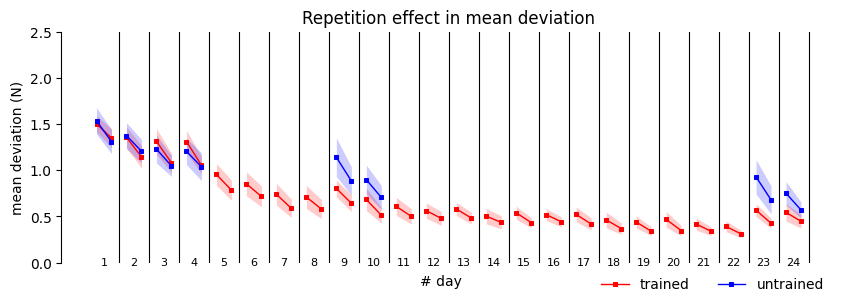

In [15]:
fig, ax = plt.subplots(figsize=(10, 3))
plot_rep(fig, ax, dat_s, metric='MD', ylim=[0, 2.5], ylabel='mean deviation (N)', title='Repetition effect in mean deviation')
plt.show()